# BP coverage analysis in ARCHS4

💡 **Environment:** `clamp-analyses`  

This notebook analyzes the proportion of biological processes (BP) that are represented in CLAMP models with different BP coverage settings.

Two sampling strategies are compared:
- **bp_coverage**: Study-based sampling (samples are selected by study/series)
- **bp_coverage_rs**: Random sampling (samples are selected randomly)

In [ ]:
library(here)
library(ggplot2)
library(dplyr)

## Define GetCLAMPPathwayCoverage

In [ ]:
GetCLAMPPathwayCoverage <- function(clamp.results, fdr.cutoff = 0.05) {
  # Calculates the proportion of BP pathways in the CLAMP prior information
  # matrix (C) that are significantly associated with at least one latent
  # variable (LV), the proportion of LVs with a pathway associated, and the
  # number of significant pathways per LV.
  #
  # Args:
  #   clamp.results: output of CLAMPfull() -- a list containing at minimum
  #                  $U (pathways x LVs coefficient matrix),
  #                  $C (genes x pathways prior info matrix),
  #                  $summary (data.frame with columns pathway, LV, AUC,
  #                            p_value, FDR, npos, nneg)
  #   fdr.cutoff:    FDR threshold for significance (default 0.05)
  #
  # Returns:
  #   A list with:
  #     pathway:           proportion of input pathways covered (>=1 sig LV)
  #     lv:                proportion of LVs with >=1 sig pathway
  #     sig.pathway.by.lv: number of significant pathways / number of LVs

  summary.df     <- clamp.results$summary
  input.pathways <- colnames(clamp.results$C)
  num.lvs        <- ncol(clamp.results$U)

  sig.df <- summary.df[summary.df$FDR < fdr.cutoff, ]

  sig.pathways <- unique(sig.df$pathway)
  sig.lvs      <- unique(sig.df$LV)

  return.list <- list()
  return.list$pathway           <- length(sig.pathways) / length(input.pathways)
  return.list$lv                <- length(sig.lvs) / num.lvs
  return.list$sig.pathway.by.lv <- length(sig.pathways) / num.lvs

  return(return.list)
}

## Load CLAMPfull_BP models and compute coverage

In [ ]:
output_dir <- here("output/archs4")

model_specs <- list(
  list(coverage = 1,  seed = 1), list(coverage = 1,  seed = 2), list(coverage = 1,  seed = 3),
  list(coverage = 5,  seed = 1), list(coverage = 5,  seed = 2), list(coverage = 5,  seed = 3),
  list(coverage = 10, seed = 1), list(coverage = 10, seed = 2), list(coverage = 10, seed = 3),
  list(coverage = 25, seed = 1), list(coverage = 25, seed = 2), list(coverage = 25, seed = 3),
  list(coverage = 50, seed = 1), list(coverage = 50, seed = 2), list(coverage = 50, seed = 3)
)

results_bp <- lapply(model_specs, function(spec) {
  path <- file.path(
    output_dir,
    sprintf("bp_coverage_%d_seed_%d", spec$coverage, spec$seed),
    "CLAMPfull_BP.rds"
  )
  if (!file.exists(path)) {
    warning("File not found: ", path)
    return(NULL)
  }
  model    <- readRDS(path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.05)
  data.frame(
    name               = sprintf("bp_coverage_%d_seed_%d", spec$coverage, spec$seed),
    coverage_pct       = spec$coverage,
    seed               = spec$seed,
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

results_bp_df <- do.call(rbind, Filter(Negate(is.null), results_bp))
rownames(results_bp_df) <- NULL
print(results_bp_df)

## Load CLAMPfull_BP_rs models and compute coverage (random sampling)

In [ ]:
results_rs <- lapply(model_specs, function(spec) {
  path <- file.path(
    output_dir,
    sprintf("bp_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    "CLAMPfull_BP.rds"
  )
  if (!file.exists(path)) {
    warning("File not found: ", path)
    return(NULL)
  }
  model    <- readRDS(path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.05)
  data.frame(
    name               = sprintf("bp_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    coverage_pct       = spec$coverage,
    seed               = spec$seed,
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

results_rs_df <- do.call(rbind, Filter(Negate(is.null), results_rs))
rownames(results_rs_df) <- NULL
print(results_rs_df)

## BP Coverage Plots

Filter condition: **FDR < 0.05**

Study-based and random sampling ordered by sample percentage (50%, 25%, 10%, 5%, 1%).

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 6)

coverage_levels <- c("50%", "25%", "10%", "5%", "1%")

results_bp_df$coverage_label <- factor(paste0(results_bp_df$coverage_pct, "%"), levels = coverage_levels)
results_rs_df$coverage_label <- factor(paste0(results_rs_df$coverage_pct, "%"), levels = coverage_levels)

results_bp_df$strategy <- "Study-based"
results_rs_df$strategy <- "Random"
results_all <- rbind(results_bp_df, results_rs_df)
results_all$strategy <- factor(results_all$strategy, levels = c("Study-based", "Random"))

strategy_colors <- c("Study-based" = "#3498db", "Random" = "#9b59b6")

ggplot(results_all, aes(x = coverage_label, y = prop_pathway * 100, fill = strategy)) +
  geom_boxplot(colour = "black", alpha = 0.8, outlier.shape = 16, outlier.size = 2) +
  geom_jitter(width = 0.1, size = 2, colour = "black", alpha = 0.7) +
  scale_fill_manual(values = strategy_colors) +
  facet_wrap(~ strategy) +
  labs(
    x = "Proportion of samples (%)",
    y = "Pathway coverage (%)"
  ) +
  theme_bw(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    legend.position  = "none",
    axis.title       = element_text(size = 14),
    axis.text        = element_text(size = 12),
    strip.text       = element_text(size = 14)
  )

In [12]:
import pandas as pd
import os
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from pyprojroot.here import here

readRDS = ro.r["readRDS"]

base_dir = here("output/archs4")

coverages = [1, 5, 10, 25, 50]
seeds = [1, 2, 3]

results = []

for coverage in coverages:
    for seed in seeds:
        # Non-rs path
        path_nrs = os.path.join(base_dir, f"bp_coverage_{coverage}_seed_{seed}", "CLAMP_K.rds")
        # RS path
        path_rs = os.path.join(base_dir, f"bp_coverage_rs{coverage}_seed_{seed}", "CLAMP_K.rds")
        
        # Read values
        K_nrs = readRDS(path_nrs)[0] if os.path.exists(path_nrs) else None
        K_rs = readRDS(path_rs)[0] if os.path.exists(path_rs) else None
        
        results.append({
            'coverage': coverage,
            'seed': seed,
            'CLAMP_K_studybased_sampling': K_nrs,
            'CLAMP_K_random_sampling': K_rs
        })

df = pd.DataFrame(results).sort_values(['coverage', 'seed'])
print(df.to_string(index=False))

 coverage  seed  CLAMP_K_studybased_sampling  CLAMP_K_random_sampling
        1     1                        744.0                   1084.0
        1     2                        654.0                    936.0
        1     3                        756.0                   1146.0
        5     1                       1618.0                   2312.0
        5     2                       1996.0                   2324.0
        5     3                       1838.0                   1586.0
       10     1                         60.0                   1136.0
       10     2                        352.0                   2546.0
       10     3                        332.0                   2214.0
       25     1                        904.0                    978.0
       25     2                       1942.0                    684.0
       25     3                        520.0                   1902.0
       50     1                       2738.0                   2022.0
       50     2     

## K (number of LVs) by sample coverage

Full ARCHS4 model K: 2366


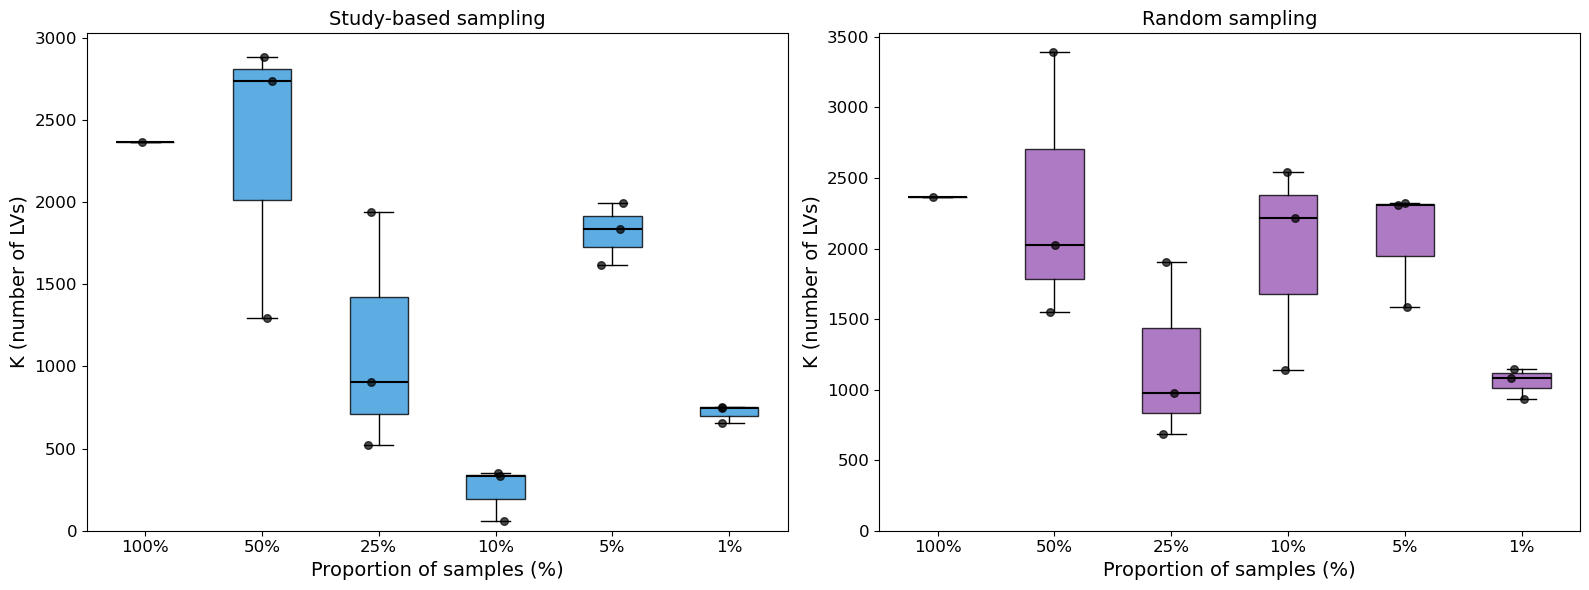

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rpy2.robjects as ro
from pyprojroot import here

readRDS = ro.r["readRDS"]

# Load K for full ARCHS4 model (100% samples, 1 repetition)
full_k_path = here("output/archs4/CLAMP_K_archs4.rds")
K_full_archs4 = int(readRDS(str(full_k_path))[0]) if os.path.exists(str(full_k_path)) else None
print(f"Full ARCHS4 model K: {K_full_archs4}")

coverage_levels = [100, 50, 25, 10, 5, 1]
coverage_labels  = ["100%", "50%", "25%", "10%", "5%", "1%"]

# K values per coverage group (study-based and random sampling)
study_k  = {100: [K_full_archs4]}
random_k = {100: [K_full_archs4]}
for cov in [50, 25, 10, 5, 1]:
    study_k[cov]  = df[df["coverage"] == cov]["CLAMP_K_studybased_sampling"].dropna().tolist()
    random_k[cov] = df[df["coverage"] == cov]["CLAMP_K_random_sampling"].dropna().tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

np.random.seed(42)
for ax, k_data, title, color in [
    (axes[0], study_k,  "Study-based sampling", "#3498db"),
    (axes[1], random_k, "Random sampling",       "#9b59b6"),
]:
    all_data   = [k_data[cov] for cov in coverage_levels]
    all_labels = coverage_labels
    all_colors = [color] * len(coverage_levels)

    bp = ax.boxplot(
        all_data, positions=range(len(all_data)), widths=0.5,
        patch_artist=True, showfliers=True,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black"), capprops=dict(color="black"),
    )
    for patch, c in zip(bp["boxes"], all_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)

    for i, data in enumerate(all_data):
        jitter = np.random.uniform(-0.1, 0.1, len(data))
        ax.scatter(np.full(len(data), i) + jitter, data,
                   color="black", s=30, alpha=0.7, zorder=5)

    ax.set_xticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels, fontsize=12)
    ax.set_ylabel("K (number of LVs)", fontsize=14)
    ax.set_xlabel("Proportion of samples (%)", fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.set_ylim(0, None)
    ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.show()